---
© [2026] Developed as part of the DIGIQ project by 
- Mehdi AYOUZ - CentraleSupélec - mehdi.ayouz@centralesupelec.fr
- Viatcheslav KOKOOULINE - UNIVERSITY OF CENTRAL FLORIDA - slavako@gmail.com
- Mariya SOSNOVA - CentraleSupélec - mariya.v.sosnova@gmail.com

---

# Quantum Cryptography: Principles of Quantum Physics Applied to Information Processing

The **objective** of this module is to introduce students to the fundamental principles of quantum cryptography and demonstrate how quantum physics concepts can be applied to ensure secure information processing, data transmission and communication. Students will acquire the necessary quantum foundations and understand how quantum phenomena such as superposition, measurement, and entanglement provide new approaches to cryptographic security. At the end of this module, students will be able to describe and analyze a quantum cryptographic protocols (for example BB84), explaining its operation and security principles.

In [ ]:
# Import necessary libraries for building, simulating, and visualizing quantum circuits:
# - Qiskit: for creating quantum circuits, manipulating states, and running simulations
# - Qiskit Aer: for simulating quantum circuits on a classical backend
# - Qiskit visualization: for Bloch sphere and measurement histogram plotting

# from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


from qiskit.circuit import Measure
from IPython.display import clear_output, display
import numpy as np
import matplotlib.pyplot as plt 

## 1. Introduction: Why do we need quantum cryptography?

**[Cryptography](https://www.ibm.com/think/topics/cryptography)** is the study of methods and techniques for developing and using coded algorithms to protect and secure transmitted information so that it can only be accessed by authorized parties possessing the appropriate decryption mechanism or key. In other words, cryptography protects communication by preventing unauthorized access to information. Its primary objective is to ensure confidentiality, integrity, authentication, and other related security properties.

Modern cryptography exists at the intersection of several disciplines, including mathematics, computer science, information security, electrical engineering, digital signal processing, and, more recently, quantum physics and quantum information science.

Main goals of cryptography (related to the [CIA triad](https://www.techtarget.com/whatis/definition/Confidentiality-integrity-and-availability-CIA?utm_source)):

- <b>Confidentiality</b> — ensures that information is accessible only to authorized parties.
- <b>Integrity</b> — ensures that information has not been altered during storage or transmission.
- <b>Authentication</b> — verifies the identity of the parties involved in communication and confirms the origin of information.
- Non-repudiation — provides proof of origin and prevents parties from denying their actions or participation in communication.

---

### 1.1. Transition from Classical Cryptography to Quantum Cryptography

Cryptography has a long history during which its definitions, purposes, and beneficiaries have radically changed, evolving from a heuristic set of tools aimed at ensuring secret military communication into a scientific discipline that secures digital systems used daily by people around the world [1]().

<b>Classical cryptography</b> was traditionally defined as “the art of writing or solving codes” and was primarily concerned with linguistic and alphabetic patterns. The main classical cipher types were <i>transposition ciphers</i>, which rearrange the order of letters in a message, and <i>substitution ciphers</i>, which systematically replace letters or groups of letters with other symbols. <u>Caesar cipher</u>, the <u>Vigenère cipher</u> are the famous examples of classical cryptographic methods.

The principle that cryptographic security should rely on secret keys rather than secret algorithms (Kerckhoffs’s Principle) remains fundamental in modern cryptography.

Building upon this principle, modern cryptographic research focuses on two main directions: **the secure exchange of cryptographic keys** and **the design of cryptographic algorithms**. These two objectives are closely related, since secure communication requires both a reliable method for establishing secret keys and efficient algorithms for protecting information.

Beginning in the 1970s - 1980s, <b>modern cryptography</b> evolved into a discipline based on mathematical theory and computer science. Modern cryptographic algorithms are designed around computational hardness assumptions, making them practically infeasible to break. Unlike classical cryptography, where secrecy often depended on hiding the encryption method itself, modern cryptography relies on publicly known algorithms and secret cryptographic keys.

There are two main types of cryptosystems [2, 3]:

| Feature | Symmetric Cryptography | Asymmetric Cryptography |
|---|---|---|
| Principle | The same secret key is used for encryption and decryption. | Different keys are used: a public key for encryption and a private key for decryption. |
| Examples | <u>AES</u> — modern symmetric block cipher <br> <u>DES</u> — early symmetric encryption standard <br> <u>One-Time Pad </u> — symmetric encryption method based on a truly random secret key used only once | <u>RSA</u> — based on integer factorization <br> <u>ECC</u> (Elliptic Curve Cryptography) — based on the elliptic-curve discrete logarithm problem <br> <u>Diffie–Hellman</u> — key exchange protocol |
| Advantages | Fast and efficient for large amounts of data | Secure key exchange and digital signatures |
| Limitations | Key distribution problem: the shared secret key must be securely exchanged before communication begins. | Computationally expensive |
| Illustration | <div align="center"><img src="Figures_QC/Symmetric_Cryptography_2.png" width="300"></div> | <div align="center"><img src="Figures_QC/Public_key_cryptography.png" width="300"></div> |


### 1.2. Exercises in Classical Cryptography 

#### 1.2.1. Exercise 1: Caesar Cipher
The <u>Caesar cipher</u> is a symmetric substitution cipher. Encryption is performed by shifting each letter forward by a fixed number of positions, while decryption is performed by shifting each letter backward by the same amount [1].

<i>To understand the basic principles of encryption and decryption, use the Caesar cipher with the English alphabet. Write a Python program that encrypts a message using a shift of N positions. Then use the same program to decrypt the encrypted message and recover the original plaintext.</i>

In [1]:
''' 
     Exercise 1: Principle of the Caesar Cipher Encryption

    Letter → Alphabet position → Shift by N positions → New letter → Ciphertext

'''

def caesar_encrypt(message, shift):
    encrypted = ""

    for char in message:
        if char.isalpha():
            if char.isupper():
                encrypted += chr((ord(char) - ord('A') + shift) % 26 + ord('A'))
            else:
                encrypted += chr((ord(char) - ord('a') + shift) % 26 + ord('a'))
        else:
            encrypted += char

    return encrypted

def caesar_decrypt(ciphertext, shift):
    return caesar_encrypt(ciphertext, -shift)

#########################################################################################################################
message = "QUANTUM CRYPTOGRAPHY"
shift = 3

ciphertext = caesar_encrypt(message, shift)
plaintext = caesar_decrypt(ciphertext, shift)

print("Original message :", message)
print("Encrypted message:", ciphertext)
print("Decrypted message:", plaintext)

Original message : QUANTUM CRYPTOGRAPHY
Encrypted message: TXDQWXP FUBSWRJUDSKB
Decrypted message: QUANTUM CRYPTOGRAPHY


#### 1.2.2. Exercise 2: XOR Encription

XOR (Exclusive OR) encryption is a simple symmetric encryption method in which each bit of the plaintext (A) is combined with a corresponding bit of a secret key (B) using the XOR logical operation. The same key is used for both encryption and decryption because applying the XOR operation twice with the same key restores the original message: 

$$ A \oplus B \oplus B = A $$

In [2]:
'''
     Exercise 2: Principle of XOR Encryption:

        Letter → ASCII code → Binary representation
        ↓
        Key → ASCII code → Binary representation
        ↓
        XOR operation
        ↓
        Encrypted binary value
        ↓
        Ciphertext
    
    Plaintext letter: H
    ASCII code: 72
    Binary: 01001000

    Key letter: S
    ASCII code: 83
    Binary: 01010011

    XOR:
    01001000
    ⊕ 
    01010011
    ----------
    00011011

    Ciphertext: 00011011 (decimal value 27)

'''

def xor_encrypt_decrypt(message, key):
    result = ""

    for i in range(len(message)):
        xor_value = ord(message[i]) ^ ord(key[i % len(key)])
        result += chr(xor_value)

    return result


message = "HELLO WORLD"
key = "SECRET"

ciphertext = xor_encrypt_decrypt(message, key)
decrypted_message = xor_encrypt_decrypt(ciphertext, key)

print("Original message :", message)
print("Key              :", key)
print("Ciphertext codes :", [ord(c) for c in ciphertext])
print("Decrypted message:", decrypted_message)

Original message : HELLO WORLD
Key              : SECRET
Ciphertext codes : [27, 0, 15, 30, 10, 116, 4, 10, 17, 30, 1]
Decrypted message: HELLO WORLD


#### 1.2.3. Exercise 3: One-Time Pad
<u>One-Time Pad (OTP)</u> is a symmetric encryption method in which a message is encrypted using a truly random secret key that is the same length as the message and used only once. When these conditions are satisfied, the One-Time Pad provides perfect secrecy and is theoretically unbreakable. However, its practical use is limited by the difficulty of securely distributing and managing the secret key. 

The One-Time Pad is commonly implemented using the XOR operation on binary data. Here, for simplicity, an alphabet-based implementation is used.

In [3]:
''' 
 Exercise 3: Principle of One-Time Pad Encryption:

1. Using the XOR operation (practical implementation):

Plaintext (binary)
        ⊕
Secret Key (binary)
        ↓
   Ciphertext

2. Using modular addition (used here for simplicity):

Plaintext letter → Alphabet position
        +
Secret Key letter → Alphabet position
        ↓
    New letter → Ciphertext


- The key must be random.
- The key must have the same length as the message.
- The key must be used only once.    
'''


import random
import string

alphabet = string.ascii_uppercase + string.ascii_lowercase  # ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


def generate_key(message):
    key = ""

    for char in message:
        if char in alphabet:
            key += random.choice(alphabet)
        else:
            key += char

    return key


def one_time_pad_encrypt(message, key):
    ciphertext = ""

    for m, k in zip(message, key):
        if m in alphabet:
            m_index = alphabet.index(m)
            k_index = alphabet.index(k)
            c_index = (m_index + k_index) % 26
            ciphertext += alphabet[c_index]
        else:
            ciphertext += m

    return ciphertext


def one_time_pad_decrypt(ciphertext, key):
    plaintext = ""

    for c, k in zip(ciphertext, key):
        if c in alphabet:
            c_index = alphabet.index(c)
            k_index = alphabet.index(k)
            m_index = (c_index - k_index) % 26
            plaintext += alphabet[m_index]
        else:
            plaintext += c

    return plaintext


# Example
message = "QUANTUM CRYPTOGRAPHY"

key = generate_key(message)

ciphertext = one_time_pad_encrypt(message, key)
decrypted_message = one_time_pad_decrypt(ciphertext, key)

print("Message:", message)
print("Key:", key)
print("Ciphertext:", ciphertext)
print("Decrypted message:", decrypted_message)

Message: QUANTUM CRYPTOGRAPHY
Key: lDOmIET eYrxXLLEynTX
Ciphertext: BXOZBYF GPPMQZRVYCAV
Decrypted message: QUANTUM CRYPTOGRAPHY


In <u>symmetric cryptography, the same secret key is used for both encryption and decryption</u>; therefore, both parties must possess the key in advance. If an attacker intercepts the key during distribution, all subsequent encrypted communication can be compromised. At the same time, the <u>One-Time Pad</u> provides theoretically perfect secrecy, but its practical use is constrained by the requirement that the secret key must be at least as long as the message, truly random, used only once, and securely distributed between the communicating parties.

This challenge is known as the **key distribution problem**, which is one of the main limitations of symmetric cryptography and a major motivation for the development of **public-key cryptography** and, later, **quantum key distribution** (QKD).

#### 1.2.4. Exercise 4: Public-Key Cryptography with RSA

RSA (Rivest–Shamir–Adleman) is a public-key cryptographic algorithm that uses two different keys: a public key for encryption and a private key for decryption. Its security relies on the computational difficulty of factoring large integers. RSA is widely used for secure communication, digital signatures, and key exchange.

For generate the private and public keys:
- Choose two prime numbers $p$ and $q$;
- Compute: 
$$ \phi (n) = (p - 1)(q - 1)$$
- Choose a public exponent $e$;
- Compute the private exponent 
$$ d = e \times d \equiv 1 \pmod{\phi(n)}; $$
- Construct: **Public key**: ($e,n$) and **Private key**: (d,n);
- Encrypt a message $M$: 
$$ C = M^e(\text{mod } n); $$
- Decrypt the ciphertext $C$: 
$$ M = C^d (\text{mod } n). $$

In [4]:
'''
Exercise 4: RSA Encryption

Principle:
Plaintext
    ↓
Public Key (e, n)
    ↓
Ciphertext
    ↓
Private Key (d, n)
    ↓
Plaintext


For understanding the basic principles of public-key cryptography in this exercise:
- Generate an RSA public and private key pair using the provided Python code.
- Encrypt a short message using the public key.
- Decrypt the ciphertext using the private key.
- Verify that the decrypted message matches the original plaintext.

'''

p = 17
q = 11

n = p * q
phi = (p - 1) * (q - 1)

e = 7
d = pow(e, -1, phi)

message = 190

message = str(message)
# Encryption
ciphertext = []

for char in message:
    m = ord(char)              # Character -> ASCII number
    c = pow(m, e, n)           # RSA encryption
    ciphertext.append(c)

# Decryption
decrypted_message = ""

for c in ciphertext:
    m = pow(c, d, n)             # RSA decryption
    decrypted_message += chr(m)  # ASCII number -> Character

print("Original message :", message)
print("Ciphertext       :", ciphertext)
print("Public key       :", (e, n))
print("Private key      :", (d, n))
print("Decrypted message:", decrypted_message)

Original message : 190
Ciphertext       : [25, 150, 159]
Public key       : (7, 187)
Private key      : (23, 187)
Decrypted message: 190


Although RSA can be used to encrypt messages directly, it is computationally expensive and inefficient for large amounts of data. Modern cryptographic systems typically use **RSA**:
- to **securely exchange a symmetric encryption key**, while the actual data are encrypted using a faster symmetric algorithm such as AES (Advanced Encryption Standard), wich supports key lengths of 128, 192, and 256 bits.
- to **create digital signatures**, which provide authentication, integrity, and non-repudiation. A digital signature allows the receiver to verify the origin of a message and confirm that its contents have not been modified.

The **security of RSA** is based on <u>the computational difficulty</u> of factoring large integers. Classical computers are currently unable to efficiently factor the large numbers used in practical RSA systems. However, a sufficiently powerful quantum computer could use **Shor's algorithm** to factor these numbers efficiently, <u>potentially compromising RSA security</u>. This limitation motivates the development of **post-quantum cryptography**, which aims to design cryptographic algorithms resistant to quantum attacks, and **quantum cryptography**, which bases security on the laws of quantum mechanics rather than on computational assumptions.

### 1.3. Limitations of Classical Cryptography

The security of many **classical cryptographic algorithms** relies on the assumption that certain **mathematical problems are computationally difficult to solve**. For example, the security of RSA is based on the difficulty of factoring large integers, while Diffie–Hellman and Elliptic Curve Cryptography (ECC) rely on variants of the discrete logarithm problem.

In [5]:
''' 
    Exercise 5: The vulnerability of the Caesar cipher to brute-force attacks 

'''

ciphertext = "TXDQWXP FUBSWRJUDSKB"
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def caesar_decrypt(ciphertext, shift):
    result = ""
    for char in ciphertext:
        if char in alphabet:
            index = alphabet.index(char)
            new_index = (index - shift) % 26
            result += alphabet[new_index]
        else:
            result += char
    return result

for shift in range(1, 26):
    print("Shift:", shift, "→", caesar_decrypt(ciphertext, shift))


Shift: 1 → SWCPVWO ETARVQITCRJA
Shift: 2 → RVBOUVN DSZQUPHSBQIZ
Shift: 3 → QUANTUM CRYPTOGRAPHY
Shift: 4 → PTZMSTL BQXOSNFQZOGX
Shift: 5 → OSYLRSK APWNRMEPYNFW
Shift: 6 → NRXKQRJ ZOVMQLDOXMEV
Shift: 7 → MQWJPQI YNULPKCNWLDU
Shift: 8 → LPVIOPH XMTKOJBMVKCT
Shift: 9 → KOUHNOG WLSJNIALUJBS
Shift: 10 → JNTGMNF VKRIMHZKTIAR
Shift: 11 → IMSFLME UJQHLGYJSHZQ
Shift: 12 → HLREKLD TIPGKFXIRGYP
Shift: 13 → GKQDJKC SHOFJEWHQFXO
Shift: 14 → FJPCIJB RGNEIDVGPEWN
Shift: 15 → EIOBHIA QFMDHCUFODVM
Shift: 16 → DHNAGHZ PELCGBTENCUL
Shift: 17 → CGMZFGY ODKBFASDMBTK
Shift: 18 → BFLYEFX NCJAEZRCLASJ
Shift: 19 → AEKXDEW MBIZDYQBKZRI
Shift: 20 → ZDJWCDV LAHYCXPAJYQH
Shift: 21 → YCIVBCU KZGXBWOZIXPG
Shift: 22 → XBHUABT JYFWAVNYHWOF
Shift: 23 → WAGTZAS IXEVZUMXGVNE
Shift: 24 → VZFSYZR HWDUYTLWFUMD
Shift: 25 → UYERXYQ GVCTXSKVETLC


This exercise demonstrates a fundamental limitation of classical ciphers: a small key space significantly reduces security. The Caesar cipher can be broken by testing all possible keys, highlighting the importance of large key spaces in modern cryptographic systems.

Estimation of a brute-force attack on AES-128, that uses a 128-bit key, resulting in $2^{128}$ possible keys. If an attacker can test $10^{12}$ keys per second, the time required to exhaust the entire key space is:

$$ t = \frac{2^{128}}{10^{12}}\text{seconds} \approx 1.08×10^{19} \text{years}$$

This demonstrates that a brute-force attack against AES-128 is computationally infeasible with current classical computing technology.

Advances in computational power and the development of quantum computers may challenge these assumptions. In particular, a sufficiently large-scale quantum computer could efficiently solve the mathematical problems underlying many current public-key cryptosystems using Shor's algorithm. As a result, cryptographic methods currently used for secure key exchange may become vulnerable.

These limitations motivated the development of **quantum cryptography**, where **security is based on the laws of quantum mechanics** rather than on computational complexity. Quantum Key Distribution (QKD) protocols, such as BB84, enable two parties to establish a shared secret key while providing the ability to detect the presence of an eavesdropper.

## 2.Fundamental Concepts of Quantum Information and Computing

### 2.1. The Postulates of Quantum Mechanics

The mathematical framework of quantum computing is based on four fundamental concepts: **state vectors**, **unitary evolution**, **measurement operators**, and **tensor products**, which correspond to the four postulates of quantum mechanics presented below [4].

<u>Postulate 1</u> (**State Vector**): Associated with any isolated quantum system is a complex vector space with an inner product (a Hilbert space), called the state space of the system. The system is completely described by its state vector $|\psi \rangle $, which is a unit vector in this space.

*In quantum computing*:
- Represents qubits and their superpositions.
- Describes initialization of quantum registers.


<u>Postulate 2 </u> (**Unitary Evolution**): The evolution of a closed quantum system from time $t_0$ to $t_1$ is described by the unitary transformation:
$$
    |\psi(t_1)\rangle = U |\psi(t_0)\rangle, \quad U^\dagger U = I
$$

*In quantum computing*:
- Quantum gates correspond to unitary operators.
- The state $|\psi \rangle $ changes via quantum gates.
- All quantum algorithms are sequences of unitary operations (quantum circuits).
- Ensures reversibility of quantum computation.

<u>Postulate 3</u> (**Measurement Operators**): Quantum measurements are described by a collection of **measurement operators** $\{ M_m \}$, acting on the state space of the system. Each operator corresponds to a possible measurement outcome $m$.

If the system is in the state $|\psi \rangle $ immediately before the measurement, the probability of obtaining outcome $m$ is
$$
p(m) = \langle \psi | M_m^\dagger M_m | \psi \rangle.
$$


The state of the system after measurement becomes

$$
    | \psi \rangle \xrightarrow{\text{Measurement}}  \frac{M_m |\psi \rangle}{\sqrt{{\langle\psi|} M_m^\dagger M_m |\psi \rangle}}.
$$

The measurement operators satisfy the completeness relation

$$
\sum_m M_m^\dagger M_m = I,
$$

which ensures that the probabilities of all possible outcomes sum to one:

$$
 \sum_m p(m) = \sum_m \langle \psi | M_m^\dagger M_m | \psi \rangle = 1 .
$$ 

*In quantum computing*:

- Explains probabilistic outcomes and collapse of superpositions.
- Converts qubit superpositions into classical bits for readout.
- Determines the output of quantum algorithms.
- Implements projective measurements in quantum circuits.


<u>Postulate 4</u> (**Tensor Products**):
The state space of a composite physical system is the tensor product of the state spaces of its subsystems. If subsystem $i$ is prepared in the state $|\psi_i\rangle $, the joint state of the total system is $ |\psi_1\rangle \otimes | \psi_2 \rangle \otimes ... \otimes  |\psi_n\rangle$

*In quantum computing*:

- Describes multi-qubit systems and entanglement.
- Allows operations on subsystems or individual qubits.
- Fundamental for quantum circuits, quantum teleportation, and entanglement-based algorithms.

### 2.2. Qubits

Like classical bits, qubits (quantum bits) are the basic units of quantum information. The concept of a qubit directly follows from Postulate 1 (State Space).
A classical bit can exist in exactly one of two states, 0 or 1. In contrast, a qubit can exist in a superposition of these states. 

The computational basis states of a qubit are denoted
$$
|0 \rangle \equiv \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad 
|1 \rangle \equiv \begin{bmatrix} 0 \\ 1 \end{bmatrix},
$$
which form an orthonormal basis of a two-dimensional complex Hilbert space.

According to the vector-space framework of quantum mechanics, the state of a qubit can be expressed as a linear combination of the computational basis states:
$$
|\psi \rangle = \alpha |0 \rangle + \beta |1 \rangle  \equiv 
\begin{bmatrix} \alpha \\ \beta \end{bmatrix}, \tag{1}
$$

where $\alpha, \beta \in \mathbb{C}$ are probability amplitudes, satisfying the normalization condition
$$
    |\alpha|^2 + |\beta|^2 = 1.
$$

Equation (1) illustrates the principle of superposition: a qubit can exist in a linear combination of the basis states $|0 \rangle$ and $|1 \rangle$, allowing infinitely many possible quantum states beyond the two classical states. 0 and 1.

A pure state of a single qubit can be visualized geometrically as a point on the Bloch sphere:

$$ |\psi \rangle = \cos \frac{\theta}{2} |0 \rangle + e^{i \phi} \sin \frac{\theta}{2} |1 \rangle , \tag{2} $$

$$
\alpha = \cos \frac{\theta}{2}, \quad \beta = e^{i \phi} \sin \frac{\theta}{2},
$$

where the amplitudes are parameterized by the polar and azimuthal angles $\theta, \phi \in \mathbb{R}$. For a single qubit, the global phase factor has no physically observable effect and can be omitted. After removing the global phase, $\alpha$ can be taken as real.


<div style="text-align: center;">
<img src="Figures_QC/Bloch sphere.png" alt="Bloch sphere" width="20%"  />

Fig.1. Bloch sphere: geometrical representation of the state vector of a single qubit system in spherical coordinates. 
</div>

A qubit state can be expressed in different but equivalent ways. Equation (1) presents the state in both Dirac notation and column-vector form, which are commonly used in theoretical analysis, quantum algorithms, and numerical simulations. Equation (2) provides the Bloch sphere representation, where the state is parameterized by two angles and visualized as a point on the surface of the Bloch sphere, offering a useful geometric interpretation of a qubit.

Initial qubit state: |𝜓⟩ = (1.000+0.000j)|0⟩ + (0.000+0.000j)|1⟩ 


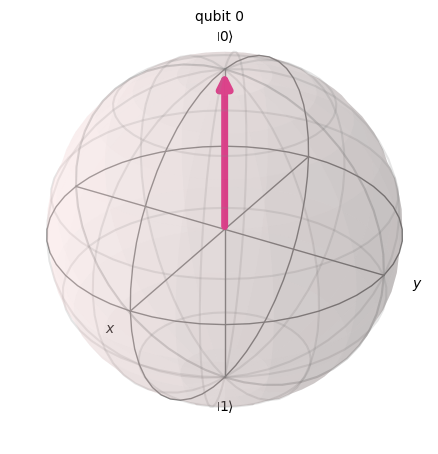

In [39]:
'''    
    Exercise 6: Visualizing Qubit States on the Bloch Sphere
'''
# Create a quantum circuit containing one qubit
qc = QuantumCircuit(1)

# Obtain the state vector
state = Statevector(qc)

print(f"Initial qubit state: |𝜓⟩ = ({state[0]:.3f})|0⟩ + ({state[1]:.3f})|1⟩ ")

# Display the Bloch sphere representation
display(plot_bloch_multivector(state))

A qubit is an abstract unit of quantum information that can be implemented using different physical systems with two distinguishable quantum states. Common realizations include photon polarization, superconducting circuits, trapped ions, electron or nuclear spins, and neutral atoms.

In quantum cryptography, qubits are most commonly implemented using **photons** where the quantum states are represented by different polarization states (e.g., horizontal/vertical or diagonal polarization), since they can be transmitted through optical fibers and free-space communication channels.

The state of a qubit can be modified by quantum operations called <u>quantum gates</u>, which are introduced in the next section.

### 2.3. Quantum gates

<u>Quantum gates</u> are reversible, unitary, and linear operations that manipulate qubits and serve as the fundamental building blocks of quantum circuits, analogous to how classical logic gates manipulate classical bits in digital circuits. The properties of quantum gates are defined by the postulates of quantum mechanics (see Chapter 2.1, Postulate 2).  

Thus, the output state can be obtained by applying a unitary matrix $U$ to the initial state:
$$ 
    |\psi'\rangle = U |\psi\rangle 
$$ 

where $U^\dagger U = U U^\dagger = I$, and $U^\dagger$ denotes the conjugate transpose of $U$. This ensures reversibility and conservation of probability.

The table below presents commonly used single-qubit (1 - 6) and multi-qubit (7) quantum gates, along with their matrix representations and respective functions.

The table below presents the quantum gates that are most relevant to the concepts developed in this module. Gates (X), (Z), and (H) are used to manipulate single-qubit states, while the CNOT gate enables operations on multiple qubits and is fundamental for creating entanglement.

| | Name of gate | Gate symbol / Matrix equivalency | Purpose |  
| - | -----------| :----------------: | ------- |
| 1 | Pauli-I (Identity) | $ I = \begin{pmatrix}1 & 0 \\0 & 1\end{pmatrix} $ | Leaves the qubit unchanged: <br> $I\|0\rangle = \|0\rangle$ <br> $ I\|1\rangle = \|1\rangle $ | 
| 2 | Pauli-X (NOT) | $ X = \begin{pmatrix}0 & 1 \\1 & 0\end{pmatrix} $ | Similar to the classical NOT gate, <br> Flips computational basis states: <br> $ X\|{0}\rangle = \|{1}\rangle $<br> $ X\|{1}\rangle = \|{0}\rangle $ <br> Rotation by $\pi$ around the x-axis.|
| 3 | Pauli-Y | $ Y = \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix} $ | Flips the computational basis states, <br> Adds a relative phase of $ \pm i$ :<br> $ Y\|{0}\rangle = i\|{1}\rangle $ <br> $ Y\|{1}\rangle = -i\|{0}\rangle$, <br>  Rotation by $\pi$ around the y-axis. |
| 4 | Pauli-Z | $ Z = \begin{pmatrix}1 & 0 \\0 & -1\end{pmatrix} $ | Leaves $\|0\rangle$ unchanged,<br> Adds a relative phase of $\pi$ to $\|1\rangle$:  <br> $ Z\|{0}\rangle = \|{0}\rangle $<br> $ Z\|{1}\rangle = -\|{1}\rangle $, <br> Rotation by $\pi$ around the z-axis,|
| 5 | Hadamard |$ H = \frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\1 & -1\end{pmatrix} $ |Creates superposition, <br> Converts between the z and x basis: <br>  $ H\|{0}\rangle = \frac{\|{0}\rangle + \|{1}\rangle}{\sqrt{2}} $<br> $ H\|{1}\rangle = \frac{\|{0}\rangle - \|{1}\rangle}{\sqrt{2}} $ |
| 6 | Phase gate| $ S = \begin{pmatrix}1 & 0 \\0 & i\end{pmatrix} $ | Adds a relative phase of $e^{i\pi/2}$ to $\|{1}\rangle:$ <br> $ S\|{0}\rangle = \|{0}\rangle $<br> $ S\|{1}\rangle = i\|{1}\rangle $ |
| 7 | Controlled-NOT | $ \text{CNOT} =\begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix} $ | Flips target qubit if control qubit is $\|{1}\rangle $ |

One of the most important features of quantum gates is their ability to create superposition states. In particular, the Hadamard gate transforms a computational basis state into a superposition of basis states. This property is examined in the next section.

### 2.4. Quantum Superposition

The principle of **superposition** allows a quantum system to exist in a linear combination of a qubit’s basis states, $|0 \rangle$ and $|1 \rangle $. For a single qubit, the state can be written as Eq.(1). More generally, for $n$-qubit system, the state can be expressed as a superposition of all $2^n$ basis states:

$$ |\psi \rangle = \sum_{i=0}^{2^n-1} \alpha_i |i \rangle, \tag{3} $$

where $ \alpha _i \in \mathbb{C}$ and satisfy the normalization condition $\sum_{i=0}^{2^n-1} |\alpha _i |^2 = 1$. 

Here, each $|i\rangle$ represents a basis state of $n$ qubits, where the integer $i$ is written in binary form to indicate the state of each qubit.

For example, a two-qubit system has four basis states: 

$$|00 \rangle, |01 \rangle, |10 \rangle, |11 \rangle $$

which can be expressed as tensor products of the states of the first qubit $q_1$ and the second qubit $q_2$.​ In general, a basis state can be written as

$$
    |q_1 q_2 \rangle = |q_1 \rangle \otimes |q_2 \rangle.
$$

For example, $|01 \rangle = |0 \rangle \otimes |1 \rangle  $, which means the first qubit is in state $|0 \rangle$ and the second qubit is in state $|1 \rangle$.

The general state of a two-qubit system can exist in a superposition of all four basis states:

$$ |\psi\rangle = \alpha _0 |00 \rangle + \alpha _1 |01 \rangle + \alpha _2 |10 \rangle + \alpha _3 |11 \rangle, \tag{3a} $$

with $ \alpha_0, \alpha_1, \alpha_2, \alpha_3 \in \mathbb{C}$ are probability amplitudes associated with the corresponding basis states and satisfy the normalization condition $|\alpha_0|^2 + |\alpha_1|^2 + |\alpha_2|^2 + |\alpha_3|^2 = 1$.

Equivalently, the state may be represented in column-vector form as

$$ |\psi\rangle 
= \alpha_0 
\begin{bmatrix}1\\0\\0\\0\end{bmatrix}
+ \alpha_1
\begin{bmatrix}0\\1\\0\\0\end{bmatrix}
+ \alpha_2
\begin{bmatrix}0\\0\\1\\0\end{bmatrix}
+ \alpha_3
\begin{bmatrix}0\\0\\0\\1\end{bmatrix}
= \begin{bmatrix}
\alpha_0 \\
\alpha_1 \\
\alpha_2 \\
\alpha_3
\end{bmatrix}. \tag{3b}
$$

To create superposition states in quantum circuits, the **Hadamard gate** is commonly used.

Applying a Hadamard gate to the state $|{0}\rangle$ produces
$$
H|{0}\rangle
= \frac{1}{\sqrt{2}}
\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}
\begin{bmatrix} 1 \\ 0 \end{bmatrix} 
= \frac{1}{\sqrt{2}}
\begin{bmatrix} 1 \\ 1 \end{bmatrix} 
= \frac{|{0}\rangle + |{1}\rangle}{\sqrt{2}} 
= |{+}\rangle,
$$
which is an equal superposition of the basis states $|{0}\rangle$ and $|{1}\rangle$. Similarly, applying a Hadamard gate to the state $|{1}\rangle$ produces
$$
H|{1}\rangle
= \frac{1}{\sqrt{2}}
\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}
\begin{bmatrix} 0 \\ 1 \end{bmatrix} 
= \frac{1}{\sqrt{2}}
\begin{bmatrix} 1 \\ -1 \end{bmatrix} 
= \frac{|{0}\rangle - |{1}\rangle}{\sqrt{2}} 
= |{-}\rangle.
$$

The states $|{+}\rangle$ and $|{-}\rangle$ form **the diagonal (X) basis**, which plays an important role in quantum algorithms and quantum cryptographic protocols such as BB84.

By default, a qubit is created in the state |𝜓⟩ = (1.000+0.000j)|0⟩ + (0.000+0.000j)|1⟩ 


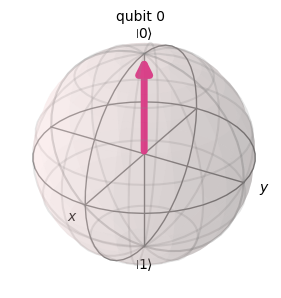

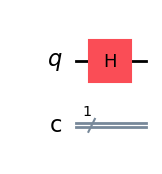

The qubit state after the application of the Hadamard gate: |𝜓⟩ = (0.707+0.000j)|0⟩ + (0.707+0.000j)|1⟩ 


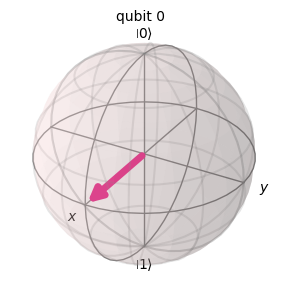

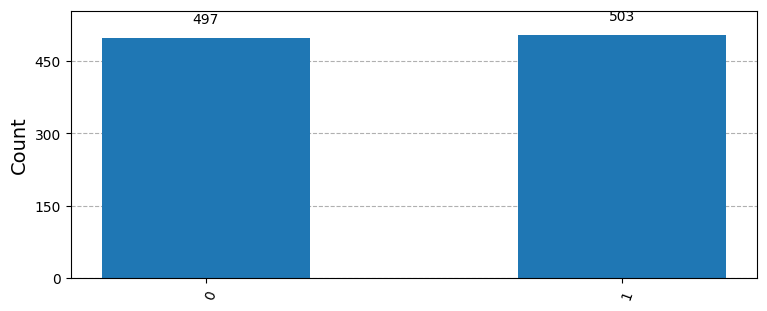

In [40]:
'''
    Exercise 7: Creating and Measuring a Superposition State
'''
# Creates a circuit with 1 qubit
qc_h = QuantumCircuit(1,1)

# Initial state
state_0 = Statevector(qc_h)
print(f"By default, a qubit is created in the state |𝜓⟩ = ({state_0[0]:.3f})|0⟩ + ({state_0[1]:.3f})|1⟩ ")

fig = plot_bloch_multivector(state_0)
fig.set_size_inches(8, 3)
display(fig)

# Apply Hadamard gate
qc_h.h(0)

# State after the application of the Hadamard gate
state_h = Statevector(qc_h)

# Draw the circuit
fig1 = qc_h.draw('mpl')
display(fig1)
print(f"The qubit state after the application of the Hadamard gate: |𝜓⟩ = ({state_h[0]:.3f})|0⟩ + ({state_h[1]:.3f})|1⟩ ")

fig2 = plot_bloch_multivector(state_h)
fig2.set_size_inches(8, 3)
display(fig2)


qc_h.measure(0, 0);


# Simulate measurements using AerSimulator
simulator = AerSimulator()
job = simulator.run(qc_h, shots=1000, memory=True)
result = job.result()

# Extract counts (histogram of results) and memory (raw shot outcomes)
counts = result.get_counts()

# Probability distribution for showing the probability distribution of measuring 0 or 1.
fig2 = plot_histogram(counts)
fig2.set_size_inches(8, 3)
display(fig2)

The previous exercise demonstrates an important feature of quantum systems: although the qubit is prepared in a superposition state, the measurement outcomes are always classical values, either 0 or 1.

This observation raises a fundamental question: <u>How does a quantum state produce classical measurement outcomes?</u>

> Quantum measurement converts quantum information into classical information. Understanding this process is essential for interpreting the results of quantum algorithms and for explaining the security of quantum cryptographic protocols.

### 2.5. Measurement

In quantum mechanics, the concept of <b>measurement</b> plays a crucial role in determining the outcome of a quantum experiment and is fundamentally different from classical measurement. The principles of quantum measurement are grounded in **Postulate 3** of quantum mechanics (see Section 2.1).

If the measurement operator $M_m$ is <i>projector </i> onto the eigenstate $|\phi_m \rangle$:

$$
    M_m = | \phi_m \rangle \langle \phi_m |,
$$

the probability of observing that outcome $m$ is given by the **Born rule**:
 
$$
    p(m) = \langle \psi | M_m |\psi \rangle =  \langle \psi | \phi_m \rangle \langle \phi_m |\psi \rangle = |\langle \phi_m |\psi \rangle|^2 \tag{5}.
$$

After the measurement, the quantum state **collapses** to the observed eigenstate $|\phi_m \rangle$:

$$
     | \psi \rangle \xrightarrow{\text{measure m}} \frac{M_m | \psi \rangle}{\sqrt{p(m)}} = |\phi_m \rangle.
$$


For a <u>single-qubit system</u> in the state $|\psi\rangle = \alpha |0 \rangle + \beta |1 \rangle $, where $|\alpha|^2 + |\beta|^2 = 1$,
the measurement operators in the computational basis are $ M_0 = |0\rangle \langle 0|$ and $ M_1 = |1 \rangle \langle 1|$.

The probabilities of measurement outcomes are
$$
    p(0) = \langle \psi | M_0 |\psi\rangle = |\alpha|^2, \quad  p(1) = \langle \psi | M_1 |\psi\rangle = |\beta|^2.
$$

The post-measurement state:

$$
    | \psi \rangle \xrightarrow{\text{measure 0}} |0\rangle, \quad | \psi\rangle \xrightarrow{\text{measure 1}} |1\rangle.
$$

For multi-qubit systems, measurement is performed in an analogous manner using measurement operators acting on the composite state space. The probabilities of different outcomes are determined by the amplitudes of the corresponding basis states. In entangled systems, measuring one qubit may affect the state of the remaining qubits due to quantum correlations. This phenomenon will be discussed in Section 2.6 (Entanglement).


---
> **Measurement** is inherently **probabilistic**: the outcome depends on the amplitudes of the qubit’s state, as given by the Born rule.

> **During measurement**, the quantum system transitions from a superposition of states to a definite state. This phenomenon, known as **state collapse** (or wavefunction collapse), is a fundamental concept of quantum mechanics.

> The **measurement process** in quantum computing is **irreversible**: performing a measurement destroys information about the original superposition, which cannot be reconstructed.

> In multi-qubit systems, **measuring one qubit** can **influence** the state of the remaining qubits if they are entangled, reflecting correlations predicted by quantum mechanics. (Postulate 4).

>Because measurement is probabilistic, quantum computers typically run the same circuit multiple times (called *shots*) to estimate the distribution of outcomes. The final result is therefore a **statistical distribution** of measurement outcomes rather than a single deterministic value.

#### Measurement Bases

A quantum state can be measured in different **bases**:

- The <u>computational basis</u> (or <u>Z basis</u>), where a measurement distinguishes between the states $|0\rangle$ and $|1\rangle$:
$$\{|0\rangle, |1\rangle \} .$$

- The <u>diagonal basis</u> (or <u>X basis</u>), where a measurement distinguishes between the states $|+\rangle$ and $|-\rangle$. Applying a Hadamard gate transforms a qubit from the computational (Z) basis to the diagonal (X) basis.
$$|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \quad |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}. $$


If a qubit prepared in one basis is measured in a different basis, the outcome becomes probabilistic. 

For example, 
$$ 
|\langle 0|+\rangle|^2 = |\langle 1|+\rangle|^2 = \frac{1}{2}, 
$$ 

so measuring the state $|+\rangle$ in the computational basis yields 0 or 1 with equal probability.

This property is fundamental to Quantum Key Distribution protocols such as BB84.  In BB84, the **computational (Z) basis** corresponds to the **rectilinear basis (+)**, while the **X basis** corresponds to the **diagonal basis (×)**. When photons are used as qubits, these bases are physically realized by **horizontal/vertical polarization** and **45°/135°** polarization, respectively.

### 2.6. Entanglement

**Quantum entanglement** is a fundamental property of quantum systems in which two or more qubits become correlated in such a way that <u>the state of one qubit cannot be described independently of the state of the others</u>, even when they are physically separated [[5]](https://doi.org/10.1103/RevModPhys.81.865). This is a uniquely quantum-mechanical phenomenon with no counterpart in classical mechanics.

The joint state of entangled qubits is inseparably linked and, in general, cannot be expressed as a product of the states of individual subsystems, in contrast to classical correlations. 

For two arbitrary quantum systems $A$ and $B$, with respective Hilbert spaces $H_A$ and $H_B$ :

<u>A pure state $|\psi \rangle \in H_A \otimes H_B$ is **entangled** if</u> it cannot be written as a **tensor product** of subsystem qubit states:

$$ |\psi \rangle \neq |\psi_A\rangle \otimes |\psi_B\rangle $$

---
The canonical examples of maximally entangled two-qubit states, known as the <u>Bell states</u> [1, 6], are:

$$ |\Phi^\pm \rangle = \frac{|00\rangle \pm |11\rangle}{\sqrt{2}}, \tag{6} $$
$$ |\Psi^\pm \rangle = \frac{|01\rangle \pm |10\rangle}{\sqrt{2}}, \tag{7} $$

When two qubits are entangled, measuring one qubit determines the correlated outcome of the other. Although individual measurement outcomes are random, their joint outcomes exhibit strong correlations. In this sense, measurement causes the **collapse of the joint quantum state**, instantaneously determining the correlated outcome of the other qubit, regardless of the spatial separation between them.

For example, in the entangled state $|\Psi^+ \rangle$, if each qubit is measured in the computational basis ${|0\rangle, |1\rangle}$, the outcomes are perfectly anti-correlated. The joint measurement yields either $|01\rangle $ or $|10\rangle$ with equal probability. Thus, if the first qubit is found in state $|0\rangle$ the second qubit is always found in $|1\rangle$, and vice versa. Such correlations have been confirmed experimentally in systems involving entangled photons, electrons, and molecules.

Quantum entanglement is a key resource in quantum information processing. It underlies quantum teleportation, quantum error correction, and provides a fundamental advantage in many quantum algorithms. It also plays a central role in quantum cryptography, particularly in entanglement-based Quantum Key Distribution protocols such as E91.

#### Exercise 8: Creation entranglement

The **CNOT gate** (see Section 2.3), combined with a **Hadamard gate**, provides one of the simplest ways to create and demonstrate quantum **entanglement**.

How it works:

- Start with a two-qubit system in the initial state $|0 0\rangle$. The computational basis states are written in the order  $|q_1 q_0\rangle$, where $q_1$ is the control qubit (left) and $q_0$ is the target qubit (right).


- Apply a <u>Hadamard gate</u> to the first qubit (the control qubit) to create a superposition on it:

$$
    H|0\rangle \otimes |0\rangle =\left( \frac{|0\rangle + |1\rangle}{\sqrt{2}} \right) \otimes |0\rangle = \frac{|00\rangle + |10\rangle}{\sqrt{2}},
$$

The two-qubit system is now in a superposition of the states $|00\rangle $ and $ |10\rangle $. The first qubit is in a superposition of 0 and 1, while the second qubit remains in state $|0\rangle $.


- Apply a CNOT gate, which flips the target qubit only if the control qubit is 1 (standard gate action):

$$
\text{CNOT} \left( \frac{|00\rangle + |10\rangle}{\sqrt{2}} \right)
= \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

The resulting state cannot be expressed as a tensor product of two individual qubit states and is therefore entangled. So, these <u>two qubits are now maximally **entangled**, forming one of the four **Bell state**</u> [[6]](https://doi.org/10.3390/quantum7030039).

By default, a qubit is created in the state |𝜓⟩ = (1.000+0.000j)|00⟩ + (0.000+0.000j)|01⟩ + 0.000+0.000j)|10⟩ + (0.000+0.000j)|11⟩  
After apply Hadamard gate |𝜓⟩ = (0.707+0.000j)|00⟩ + (0.707+0.000j)|01⟩ + 0.000+0.000j)|10⟩ + (-0.000+0.000j)|11⟩  
After apply CNOT gate |𝜓⟩ = (0.707+0.000j)|00⟩ + (0.000+0.000j)|01⟩ + 0.000+0.000j)|10⟩ + (0.707+0.000j)|11⟩  


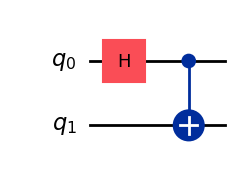

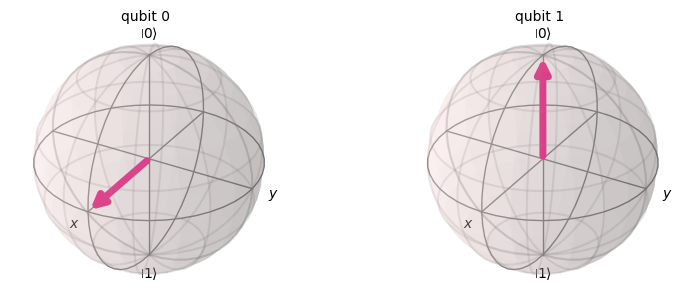

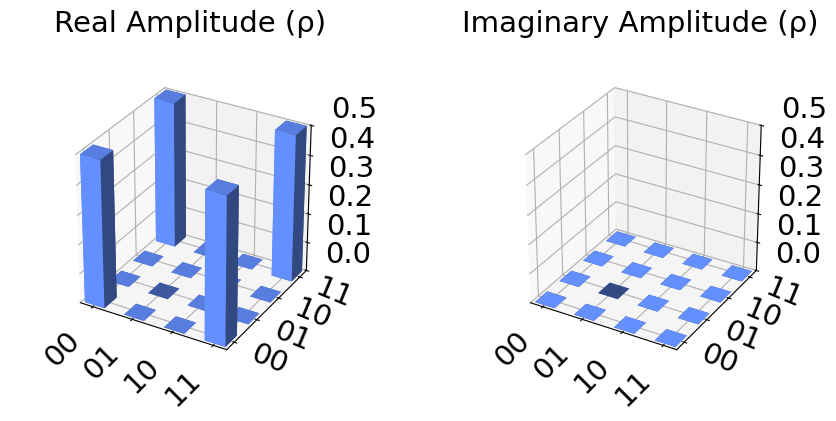

In [ ]:
'''    
    Exercise 8: Demonstrating Entanglement of Two Qubits

    The creation of a Bell state. 
    After measurement, the outcomes 00 and 11 occur with approximately equal probability, 
    while the outcomes 01 and 10 are not observed, revealing the strong correlations characteristic of quantum entanglement.

'''

# Demonstration entranglement of two qubits
from qiskit.visualization import plot_bloch_multivector, plot_state_city, plot_histogram

# Create a 2-qubit quantum circuit
qc_e = QuantumCircuit(2)
state_0 = Statevector(qc_e)

print(f"By default, a qubit is created in the state |𝜓⟩ = ({state_0[0]:.3f})|00⟩ + ({state_0[1]:.3f})|01⟩ + {state_0[2]:.3f})|10⟩ + ({state_0[3]:.3f})|11⟩  ")

# 1: Apply Hadamard gate to the left qubit to create superposition
qc_e.h(0)

state_h = Statevector(qc_e)
print(f"After apply Hadamard gate |𝜓⟩ = ({state_h[0]:.3f})|00⟩ + ({state_h[1]:.3f})|01⟩ + {state_h[2]:.3f})|10⟩ + ({state_h[3]:.3f})|11⟩  ")


# 2: Apply CNOT gate (q0=control, q1=target) to entangle the qubits
qc_e.cx(0, 1)
state_cx = Statevector(qc_e)
print(f"After apply CNOT gate |𝜓⟩ = ({state_cx[0]:.3f})|00⟩ + ({state_cx[1]:.3f})|01⟩ + {state_cx[2]:.3f})|10⟩ + ({state_cx[3]:.3f})|11⟩  ")

# Draw the quantum circuit
fig = qc_e.draw('mpl')
display(fig)

# Visualize the statevector
fig1 = plot_bloch_multivector(state_h)
fig1.set_size_inches(8,3)
display(fig1)

# Visualize the statevector
fig2 = plot_state_city(state_cx)
fig2.set_size_inches(9,4) # density-matrix
display(fig2)

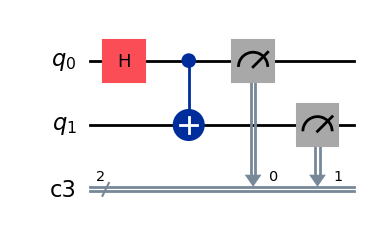

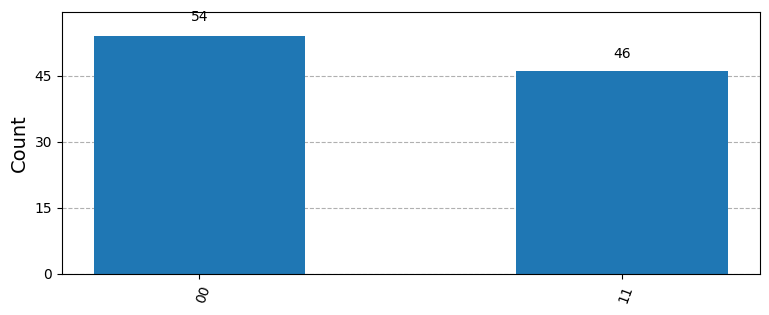

In [42]:
cr = ClassicalRegister(2) 
qc_e.add_register(cr) 
qc_e.measure([0,1], [0,1])

simulator = AerSimulator()
job = simulator.run(qc_e,  shots=100, memory=True)
result = job.result()
counts = result.get_counts(qc_e)

# Draw the final  quantum circuit
fig = qc_e.draw('mpl')
display(fig)

#Plot the histogram of measurement outcomes
fig1 =plot_histogram(counts)
fig1.set_size_inches(8, 3)
display(fig1)

**Verify that the obtained result corresponds to a maximally entangled state:**

The quantum state obtained is 
$$|\Phi^+ \rangle = (0.707+0.000j)|00\rangle + (0.000+0.000j)|01\rangle + (0.000+0.000j)|10\rangle + (0.707+0.000j)|11\rangle$$

which which is equivalent (up to numerical precision) to the Bell state  
$$ |\Phi^+ \rangle  = \frac{|00\rangle + |11\rangle}{\sqrt{2}} $$

This state is maximally entangled, as justified by the following points:

- The state  $|\Phi^+ \rangle $ cannot be decomposed as a tensor product.

- The measurement histogram shows nonzero probabilities only for the states: $|11\rangle$ and $|00\rangle$  (see histogram).

- The density matrix contains off-diagonal terms, $|00\rangle\langle11|$ and $|11\rangle\langle00|$, which represent quantum coherence between the states $|00\rangle$ and $|11\rangle$.

### 2.7. Interference and Decoherence

- Quantum **interference** arises when probability amplitudes associated with different quantum states combine. Depending on their relative phases, amplitudes may reinforce each other (constructive interference) or cancel each other (destructive interference). Quantum algorithms exploit interference to increase the probability of correct outcomes and suppress incorrect ones.

- **Decoherence** is the process by which a quantum system loses its quantum properties through interactions with the environment. As a result, superposition and entanglement gradually disappear, and the system behaves more classically. Decoherence is one of the main challenges in building quantum computers and implementing long-distance quantum communication systems.

## 3. Quantum Cryptography

### 3.1. Why Quantum Key Distribution?

    Before studying quantum cryptography itself, it is important to understand why classical and modern cryptographic techniques are not always sufficient and why quantum physics introduces a fundamentally different approach to security.

As discussed previously, symmetric cryptographic systems suffer from **the key distribution problem**: two communicating parties must share a secret key before secure communication can begin. Public-key cryptography partially addresses this challenge, but its security relies on computational assumptions that may become vulnerable to future quantum computers.

<u>The fundamental question is</u>:

    How can Alice and Bob (the conventional names for two communicating parties) establish a secret key over an insecure communication channel while ensuring that any eavesdropping attempt by Eve (an eavesdropper) can be detected?

In classical communication systems based on electrical signals, radio waves, optical pulses, or digital data streams, information can be copied and measured without fundamentally altering it. Consequently, an eavesdropper may intercept the communication channel and duplicate the transmitted information without Alice or Bob noticing.

> *An attacker could break the system if they had enough computational power or a better algorithm*.

> *Security is not absolute. Classical cryptographic depends on technological limitations*.

These limitations motivate the use of quantum communication, where quantum states cannot generally be copied or measured without disturbance. Quantum Key Distribution (QKD) exploits this fundamental property of quantum mechanics to enable the secure establishment of a shared secret key and to reveal the presence of an eavesdropper [7,8].

**Main Categories of Quantum Key Distribution Protocols according to the quantum resources and communication principles they employ.**

| Category                                       | Protocols                                                          |
| ---------------------------------------------- | ------------------------------------------------------------------ |
| **Prepare-and-Measure Protocols**              | BB84 (1984), B92 (1992), DPS-QKD (2002), SARG04 (2004), COW (2004) |
| **Entanglement-Based Protocols**               | E91 (1991), BBM92 (1992)                                           |
| **Protocols with Enhanced Practical Security** | MDI-QKD (2012), Twin-Field QKD (2018)                              |

Recent advances in quantum cryptography have focused on improving the security and practical deployment of QKD systems. In particular, **Measurement-Device-Independent QKD** (MDI-QKD) and **Twin-Field QKD** represent major developments aimed at mitigating implementation vulnerabilities and extending communication distances. Current research is also exploring **Device-Independent QKD** (DI-QKD) and **Continuous-Variable QKD** (CV-QKD) as promising directions for future quantum communication systems [9].

### 3.2. BB84 Quantum Key Distribution Protocol

The BB84 protocol, proposed by Charles Bennett and Gilles Brassard in 1984, is the first and most widely studied Quantum Key Distribution (QKD) protocol. Its purpose is to allow two parties, traditionally called Alice and Bob, to establish a shared secret key while detecting the presence of an eavesdropper (Eve).

BB84 derives its security from the laws of quantum mechanics. In particular, measuring an unknown quantum state inevitably disturbs it. Therefore, any attempt by Eve to intercept and measure the transmitted quantum information introduces detectable errors.
<div align="center">
    <img src="Figures_QC/BB84.png" width="500">
</div>

<u>Each bit is encoded into the polarization state of a photon using one of two possible bases</u>:
- Rectilinear basis (+): horizontal or vertical polarization.
- Diagonal basis (×): $45^\circ$ or $135^\circ$ polarization.
---
1. **Encode and send photons**: Alice generates a random sequence of bits and encodes each bit into the polarization state of a photon using either the rectilinear (+) or diagonal (×) basis.
2. **Measure photons**: Bob randomly chooses a measurement basis for each received photon and records the measurement results.
3. **Public discussion of bases**: Alice and Bob publicly announce the bases they used, but not the bit values.
4. **Sifting**: Alice and Bob keep only the bits corresponding to positions where their measurement bases match, forming the sifted key.
5. **Error estimation**: By comparing a randomly selected subset of the sifted key, Alice and Bob estimate the error rate and detect potential eavesdropping.
6. **Key generation**: If the error rate is sufficiently low, error correction and privacy amplification are applied to obtain a shared secret key.
7. **Eavesdropping detection**: An eavesdropper introduces disturbances when measuring quantum states, increasing the error rate and revealing their presence.
8. **Using the generated key**: The shared secret key can subsequently be used for encryption and decryption with a symmetric cryptographic algorithm, such as AES (Advanced Encryption Standard) or the One-Time Pad, or other symmetric encryption schemes. The One-Time Pad provides theoretically perfect secrecy when the key is truly random, used only once, and has the same length as the message.

<u>Why is it secure? </u>

> Security is therefore based on the laws of quantum mechanics.

> Measuring an unknown quantum state disturbs it, making eavesdropping detectable. 

#### 3.3. Applications of Quantum Cryptography

Historically, cryptography was primarily used for military, diplomatic, and national security communications to protect sensitive information from adversaries. Today, it has become an essential component of everyday digital life. Cryptographic techniques are widely used in electronic commerce, secure web communication (HTTPS), user authentication, electronic signatures, banking systems, healthcare technologies, chip-based payment cards, cryptocurrencies, and the protection of confidential information.

As a result, cryptography has become a fundamental technology for securing modern digital communications and information systems.

#### 3.3.1. Exercise: Principle of the BB84 Protocol Without Eavesdropping

The exercise demonstrates the basic principles of the BB84 Quantum Key Distribution protocol . Alice generates random bits and randomly chooses a basis (Z or X) to encode each bit into a qubit. Bob independently selects random measurement bases and measures the received qubits.

In [ ]:
''' 
Principle of the BB84 Quantum Key Distribution Protocol Without Eavesdropping

- Alice generates random bits and random bases.
- Alice encodes each bit into a qubit.
- Bob randomly chooses measurement bases.
- Alice and Bob keep only positions where their bases match.

'''

import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def bb84_qubit(alice_bit, alice_basis, bob_basis):
    qc = QuantumCircuit(1, 1)

    # Alice prepares qubit
    if alice_bit == 1:
        qc.x(0)

    if alice_basis == "X":
        qc.h(0)

    # Bob measures
    if bob_basis == "X":
        qc.h(0)

    qc.measure(0, 0)

    result = simulator.run(qc, shots=1).result()
    counts = result.get_counts()

    return int(list(counts.keys())[0])


# Example with 10 qubits
n = 10

alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(["Z", "X"]) for _ in range(n)]
bob_bases = [random.choice(["Z", "X"]) for _ in range(n)]

bob_results = []

for bit, a_basis, b_basis in zip(alice_bits, alice_bases, bob_bases):
    result = bb84_qubit(bit, a_basis, b_basis)
    bob_results.append(result)

# Sifting
sifted_key_alice = []
sifted_key_bob = []

for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        sifted_key_alice.append(alice_bits[i])
        sifted_key_bob.append(bob_results[i])

print("Alice bits  :", alice_bits)
print("Alice bases :", alice_bases)
print("Bob bases   :", bob_bases)
print("Bob results :", bob_results)

print("Alice sifted key:", sifted_key_alice)
print("Bob sifted key  :", sifted_key_bob)

# Error rate
errors = sum(a != b for a, b in zip(sifted_key_alice, sifted_key_bob))

if len(sifted_key_alice) > 0:
    error_rate = errors / len(sifted_key_alice)
else:
    error_rate = 0

print("Error rate (%)  :", error_rate * 100)


Alice bits  : [0, 0, 1, 1, 0, 1, 1, 1, 0, 1]
Alice bases : ['Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z']
Bob bases   : ['X', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'Z']
Bob results : [1, 0, 1, 1, 0, 0, 1, 1, 0, 1]
Alice sifted key: [0, 1, 1, 0, 1, 0, 1]
Bob sifted key  : [0, 1, 1, 0, 1, 0, 1]
Error rate (%)  : 0.0


#### 3.3.2. Exercise: Principle of the BB84 Protocol With Eavesdropping

In this exercise the protocol can be repeated with an eavesdropper (Eve) to illustrate the security of BB84. Eve intercepts and measures the transmitted qubits before forwarding them to Bob. Because quantum measurements disturb quantum states, Eve's intervention introduces errors into the sifted key.

By comparing a subset of their sifted key, Alice and Bob can estimate the error rate. An increased error rate indicates the possible presence of an eavesdropper.

In [ ]:
'''
Principle of the BB84 Quantum Key Distribution Protocol With Eavesdropping

- Alice generates random bits and random bases.
- Alice encodes each bit into a qubit.
- Eve intercepts each qubit and measures it using a random basis.
- Eve sends a new qubit to Bob.
- Bob randomly chooses measurement bases.
- Alice and Bob keep only positions where their bases match.
- Alice and Bob calculate the error rate.
'''

import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()


def bb84_qubit_with_eve(alice_bit, alice_basis, eve_basis, bob_basis):

    # Alice prepares qubit
    qc_eve = QuantumCircuit(1, 1)

    if alice_bit == 1:
        qc_eve.x(0)

    if alice_basis == "X":
        qc_eve.h(0)

    # Eve measures
    if eve_basis == "X":
        qc_eve.h(0)

    qc_eve.measure(0, 0)

    result = simulator.run(qc_eve, shots=1).result()
    eve_result = int(list(result.get_counts().keys())[0])

    # Eve prepares a new qubit and sends it to Bob
    qc_bob = QuantumCircuit(1, 1)

    if eve_result == 1:
        qc_bob.x(0)

    if eve_basis == "X":
        qc_bob.h(0)

    # Bob measures
    if bob_basis == "X":
        qc_bob.h(0)

    qc_bob.measure(0, 0)

    result = simulator.run(qc_bob, shots=1).result()
    bob_result = int(list(result.get_counts().keys())[0])

    return bob_result


# Example with 20 qubits
n = 20

alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(["Z", "X"]) for _ in range(n)]
eve_bases = [random.choice(["Z", "X"]) for _ in range(n)]
bob_bases = [random.choice(["Z", "X"]) for _ in range(n)]

bob_results = []

for bit, a_basis, e_basis, b_basis in zip(alice_bits, alice_bases, eve_bases, bob_bases):
    result = bb84_qubit_with_eve(bit, a_basis, e_basis, b_basis)
    bob_results.append(result)


# Sifting
sifted_key_alice = []
sifted_key_bob = []

for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        sifted_key_alice.append(alice_bits[i])
        sifted_key_bob.append(bob_results[i])


# Error rate
errors = sum(a != b for a, b in zip(sifted_key_alice, sifted_key_bob))

if len(sifted_key_alice) > 0:
    error_rate = errors / len(sifted_key_alice)
else:
    error_rate = 0


print("Alice bits  :", alice_bits)
print("Alice bases :", alice_bases)
print("Eve bases   :", eve_bases)
print("Bob bases   :", bob_bases)
print("Bob results :", bob_results)

print("Alice sifted key:", sifted_key_alice)
print("Bob sifted key  :", sifted_key_bob)

print("Error rate (%)  :", error_rate * 100)

Alice bits  : [0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1]
Alice bases : ['Z', 'X', 'X', 'Z', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'Z']
Eve bases   : ['X', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z']
Bob bases   : ['X', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X']
Bob results : [0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1]
Alice sifted key: [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1]
Bob sifted key  : [1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0]
Error rate (%)  : 20.0


| Advantages                                                 | Limitations                                                                                                |
| ---------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| Security based on the laws of quantum mechanics            | Requires specialized quantum communication equipment                                                       |
| Ability to detect the presence of an eavesdropper          | Limited communication distance compared with classical networks                                            |
| Resistant to attacks from quantum computers                | Lower key generation rates than conventional communication systems                                         |
| Provides a secure solution to the key distribution problem | Used only for key distribution; data encryption still requires a classical symmetric algorithm such as AES |


#### 3.3.3. Exercise: Gate-Based Encryption

In this exercise, the quantum version of the One-Time Pad protocol is demonstrated using Qiskit [10].

The Quantum One-Time Pad (QOTP) is a method for encrypting quantum information using a secret key. For each qubit $i \in [1,n]$, two random bits are chosen $a_i, b_i \in \{0,1\}$. These bits determine which Pauli operations are applied to the qubit:
$$ X^{a_i} Z^{b_i}. $$
To decryptthe state, the inverse operations are applied: 
$$ Z^{b_i} X^{a_i}. $$
Since Pauli gates are their own inverses, applying the correct key restores the original quantum state. Without knowledge of the key, the quantum information remains hidden.

In [ ]:
import random
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# MESSAGE TO ENCRYPT ------------------------------
message = "QCVV"

# Convert text to binary
def text_to_binary(text):
    return ''.join(format(ord(c), '08b') for c in text)

def binary_to_text(binary):
    return ''.join(chr(int(binary[i:i+8], 2)) for i in range(0, len(binary), 8))

binary = text_to_binary(message)
n = len(binary)
print("Original binary:", binary)


# INITIALIZE QUANTUM CIRCUIT ------------------------------
qc = QuantumCircuit(n, n)

# Encode classical bits into qubits
for i, bit in enumerate(binary):
    if bit == '1':
        qc.x(i)  # Encode '1' as |1>

# ENCRYPTION --- Random key for each qubit: apply X and/or Z

# Generate random keys (0 or 1) for X and Z gates
key_X = [random.randint(0,1) for _ in range(n)]
key_Z = [random.randint(0,1) for _ in range(n)]

# Apply encryption
for i in range(n):
    if key_X[i]:
        qc.x(i)
    if key_Z[i]:
        qc.z(i)

# DECRYPTION (apply same key) -----------------------------
for i in range(n):
    if key_Z[i]:
        qc.z(i)
    if key_X[i]:
        qc.x(i)

# MEASURE AND RECOVER MESSAGE ------------------------------
qc.measure(range(n), range(n))

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

# Binary result (may need reversing)
recovered_binary = list(counts.keys())[0][::-1]
recovered_message = binary_to_text(recovered_binary)

print("Original message :", message)
print("Original binary  :", binary)
print("Key X            :", key_X)
print("Key Z            :", key_Z)
print("Recovered binary :", recovered_binary)
print("Recovered message:", recovered_message)

# Draw the final  quantum circuit
print(qc)

Original binary: 01010001010000110101011001010110
Original message : QCVV
Original binary  : 01010001010000110101011001010110
Key X            : [0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1]
Key Z            : [0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1]
Recovered binary : 01010001010000110101011001010110
Recovered message: QCVV
           ┌─┐                                                               »
 q_0: ─────┤M├───────────────────────────────────────────────────────────────»
      ┌───┐└╥┘┌───┐┌───┐┌───┐┌───┐                                           »
 q_1: ┤ X ├─╫─┤ X ├┤ Z ├┤ Z ├┤ X ├───────────────────────────────────────────»
      ├───┤ ║ ├───┤├───┤├───┤└───┘                                           »
 q_2: ┤ X ├─╫─┤ Z ├┤ Z ├┤ X ├────────────────────────────────────────────────»
      ├───┤ ║ └───┘└───┘└───┘               ┌─┐                              »
 q_3: ┤ X ├─╫

Classical cryptography:
• An attacker could break the system if they had enough computational power or a better algorithm.
• Security is not absolute.

Quantum cryptography:
• An eavesdropper cannot measure quantum states without disturbing them.
• Security is based on the laws of physics rather than computational assumptions.

## Bibliography

1. J. Katz, & Y Lindell. Introduction to Modern Cryptography (2nd ed.). Chapman and Hall/CRC, 2014.

2. W.Stallings. Cryptography and Network Security: Principles and Practice, 5th ed., Prentice Hall, 2011.

3. Gisin, N., Ribordy, G., Tittel, W., & Zbinden, H. Quantum Cryptography. Reviews of Modern Physics, 74(1), 145–195, 2002. https://doi.org/10.1103/RevModPhys.74.145

4. M.A. Nielsen, I.L. Chuang.  Quantum Computation and Quantum Information: 10th Anniversary Edition. Cambridge University Press, 2010.

5. R. Horodecki, P. Horodecki, M. Horodecki and K. Horodecki. Quantum entanglement. Rev. Mod. Phys. 81, 865, 2009. https://doi.org/10.1103/RevModPhys.81.865

6. E. Grigoryan, S. Kumar, P.R. Pinheiro. A Review on Models and Applications of Quantum Computing. Quantum Rep.7, 39, 2025. https://doi.org/10.3390/quantum7030039

7. N.Jha, A.Parakh, M.Subramaniam.  Quantum key distribution: Bridging theoretical security proofs, practical attacks, and error correction for quantum-augmented networks. Cryptologia, 1–58, 2026. https://doi.org/10.1080/01611194.2025.2596885 

8. S.Pirandola, U.L. Andersen, L.Banchi, et al. Advances in Quantum Cryptography. Advances in Optics and Photonics, 12(4), 1012–1236, 2020 https://doi.org/10.1364/AOP.361502

9. F. Barrett-danes, F.Ahmad. Quantum computing and cybersecurity: a rigorous systematic review of emerging threats, post-quantum solutions, and research directions (2019–2024). Discov Appl Sci 7, 1083, 2025. https://doi.org/10.1007/s42452-025-07322-5

10. Chuanqi Xu, Jamie Sikora, and Jakub Szefer. Securing Quantum Computer Reset with One-Time Pads. In Proceedings of the 2025 Quantum Security and Privacy Workshop (QSec '25). Association for Computing Machinery, New York, NY, USA, 1–6, 2025. https://doi.org/10.1145/3733825.3765278

## Appendix: Exploring Qubits with Qiskit

For building, simulating, and visualizing quantum circuits, the open-source, Python-based, high-performance quantum computing framework [Qiskit](https://quantum.cloud.ibm.com/docs/en/guides)  is used in this notebook. Qiskit is developed by IBM Research and provides tools for creating quantum programs by defining quantum circuits and quantum operations, as well as executing them on real quantum hardware or classical simulators.

Below is a list of basic functions needed for the first steps in creating basic quantum circuits.

| Concept                          | Command / Syntax          | Description / Notes |
|-----------------------------------------|---------------------------|---------------------|
| **1. Creation of a Quantum Circuit** | `qc = QuantumCircuit(qb, b)` | `qb` - the number of qubits in the circuit, <br> `b` is the number of classical bits used to store measurement results. <br>Qubits are initialized in \|0⟩. Two qubits start as \|00⟩. <br> If no measurement is needed, the number of classical bits can be set to 0 (default).  |
| **2. Initialization of a Quantum State** | `qc.initialize([α, β], N)` |Example of initializing a One-Qubit State <br> `[α, β]` - amplitudes, must satisfy the normalization condition (see Eq.1).<br> `N` indicates which qubit is initialized.<br> If both α and β are non-zero, the qubit is in **superposition**.<br> Before measurement, qubit has no definite value. |
| **3. Extracting the Quantum State**  | `state = Statevector.(qc).data` | Run the circuit using the statevector . <br> Returns the statevector describing the qubit before measurement. |
| **4. Visualizing the Quantum State** | `plot_bloch_multivector(state)` |The Bloch sphere shows the orientation of the qubit state and provides an intuitive geometric picture of superposition for one qubit. |
| **5. Performing Measurements** | `qc.measure(qb_m, b_m)` | `qb_m` is the qubit being measured,<br> `b_m` is the classical bit where the result is stored.<br> **Important:** measurement requires a simulator or real hardware. |
| **6. Simulating Measurements** | `simulator = AerSimulator()`, <br> `job = simulator.run(qc, shots=100, memory=True)`,<br> `result = job.result()` | `shots` is the number of circuit executions,,<br> `memory=True` - stores the result of each individual measurement.  |
| **7. Output of Measurement Results** | `counts = result.get_counts()` ,<br> `memory = result.get_memory()`, <br>`plot_histogram(counts)`, <br> `qc.draw('mpl')` |  - frequency of measurement outcomes,<br>  - stores the result of each individual measurement,<br>  - shows the probability distribution for each state,<br> - draws the quantum circuit. |


For practical purposes, all quantum circuits in this notebook are executed using classical simulators.

**Important:** According to the standard convention used by [Qiskit](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering) (little-endian ordering), when displaying or interpreting a **list of qubits** (or bits) as a string, qubit `n−1` is the leftmost qubit, and qubit `0` is the rightmost. This follows the usual convention of writing numbers with the most significant digit on the left. For example, a two-qubit state is written as $|{q_1 q_0}\rangle$, where the left bit corresponds **qubit 1** and the right bit corresponds **qubit 0**. 
| Two-qubit state | Qubit 1 | Qubit 0 |
|-----------------|---------|---------|
| `00`            | 0       | 0       |
| `01`            | 0       | 1       |
| `10`            | 1       | 0       |
| `11`            | 1       | 1       |

In [ ]:
# Demonstration of ordre qubit in quantum cuircit.

from qiskit import QuantumCircuit, transpile

qc = QuantumCircuit(2, 2)

qc.x(0)                 # Flip qubit 0
qc.measure([0,1], [0,1])

sim = AerSimulator()
result = sim.run(transpile(qc, sim), shots=1024).result()

print(result.get_counts())

In [ ]:
qc = QuantumCircuit(2, 2)

qc.x(1)                 # Flip qubit 1
qc.measure([0,1], [0,1])

result = sim.run(transpile(qc, sim), shots=1024).result()

print(result.get_counts())

In [ ]:
from qiskit.quantum_info import Pauli

qc_e = QuantumCircuit(2)
state_0 = Statevector(qc_e)
qc_e.x(0)

qc_e.draw('mpl')

| Feature        | AerSimulator (your code)                         | Sampler + transpiled circuit                                 |
| -------------- | ------------------------------------------------ | ------------------------------------------------------------ |
| Simulator type | Classic shot-based simulator                     | Qiskit Runtime primitive, can be exact                       |
| Outputs        | Histogram (`get_counts`) & memory (`get_memory`) | Probabilities or expectation values                          |
| Shots          | `shots=N` determines number of runs              | Optional; by default exact probabilities                     |
| Optimization   | None by default                                  | Uses `generate_preset_pass_manager` for backend optimization |
| Use case       | Test algorithms with measurement randomness      | Compute exact statistics, variational algorithms, primitives |

service = QiskitRuntimeService(channel='ibm_quantum_platform')
backend = service.backend('ibmq_qasm_simulator')

**Define backend**
backend = AerSimulator()
**Transpile to backend**
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)
**Run the job**
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc])
result = job.result()
counts = result[0].data.c.get_counts()

- Go to IBM Quantum and sign up for free.
- After signing in, click on your profile → Account → API Token.
- Copy the API token (it’s a long string of letters/numbers).

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/bits-gates-and-circuits